In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

feature_names = housing.feature_names

print("Dataset Shape:", X.shape)
print("Features:", feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Dataset Shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
alphas = np.logspace(-3, 3, 100)

ridge_cv = RidgeCV(
    alphas=alphas,
    cv=10
)

ridge_cv.fit(X_train_scaled, y_train)

best_alpha = ridge_cv.alpha_

print("\nBest Alpha:", best_alpha)


Best Alpha: 1.629750834620645


In [5]:
ridge = Ridge(alpha=best_alpha)

ridge.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",np.float64(1.629750834620645)
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``so

In [7]:
y_pred = ridge.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== Ridge Regression Results =====")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


===== Ridge Regression Results =====
MSE  : 0.5558
RMSE : 0.7455
R²   : 0.5758


In [8]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ridge.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    key=np.abs,
    ascending=False
)

print("\nFeature Coefficients")
print(coef_df)


Feature Coefficients
      Feature  Coefficient
6    Latitude    -0.895689
7   Longitude    -0.868586
0      MedInc     0.854291
3   AveBedrms     0.338850
2    AveRooms    -0.294085
1    HouseAge     0.122673
5    AveOccup    -0.040835
4  Population    -0.002266


In [11]:
X_scaled = scaler.fit_transform(X)
alphas = np.logspace(-3, 5, 100)

coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_scaled, y)
    coefs.append(ridge.coef_)

coefs = np.array(coefs)


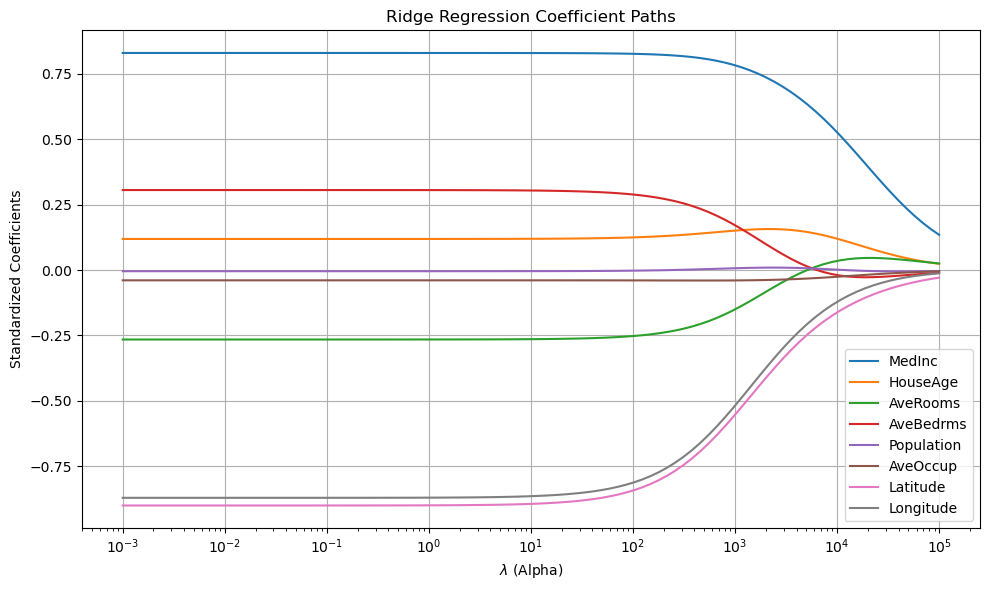

In [12]:
plt.figure(figsize=(10, 6))

for i in range(len(feature_names)):
    plt.plot(
        alphas,
        coefs[:, i],
        label=feature_names[i]
    )

plt.xscale("log")
plt.xlabel(r"$\lambda$ (Alpha)")
plt.ylabel("Standardized Coefficients")
plt.title("Ridge Regression Coefficient Paths")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

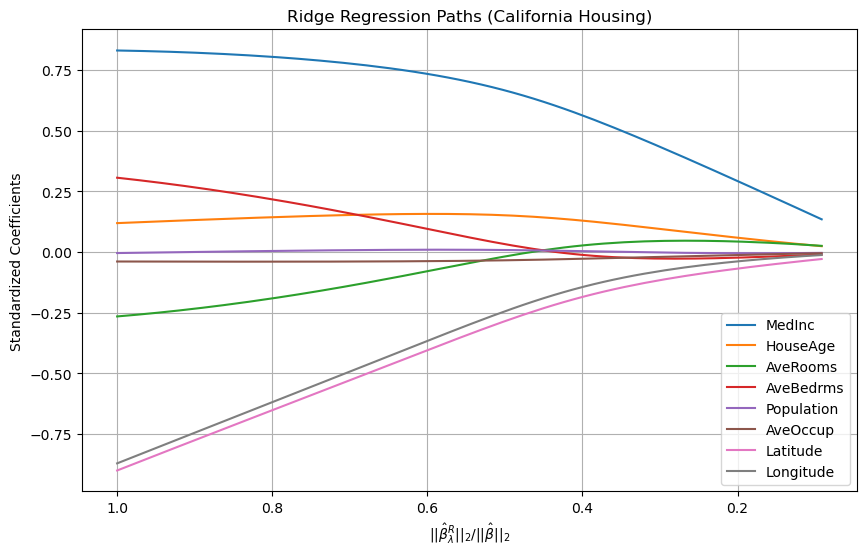

In [14]:
from sklearn.linear_model import LinearRegression

ols = LinearRegression()
ols.fit(X_scaled, y)

beta_norm = np.linalg.norm(ols.coef_)

# Ridge path
alphas = np.logspace(-3, 5, 200)

coefs = []
s_values = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_scaled, y)

    coefs.append(ridge.coef_)
    s_values.append(
        np.linalg.norm(ridge.coef_) / beta_norm
    )

coefs = np.array(coefs)

# ISLR-style plot
plt.figure(figsize=(10, 6))

for i in range(coefs.shape[1]):
    plt.plot(
        s_values,
        coefs[:, i],
        label=feature_names[i]
    )

plt.xlabel(r"$||\hat{\beta}_{\lambda}^{R}||_2 / ||\hat{\beta}||_2$")
plt.ylabel("Standardized Coefficients")
plt.title("Ridge Regression Paths (California Housing)")
plt.legend()
plt.gca().invert_xaxis()  # ISLR convention
plt.grid(True)
plt.show()